# Introduction to neuroimaging data with Python


> Adapted from [DartBrains](https://dartbrains.org/) by Luke Chang (© Luke Chang, supported by NSF CAREER Award 1848370), used under [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/). **Changes made:** trimmed to the exercise sections, setup code reduced to the cells the exercises depend on, display-only calls removed. Exercise solutions are my own work. This notebook is therefore also distributed under CC BY-SA 4.0. No endorsement by the original author is implied.


In [ ]:
from bids import BIDSLayout, BIDSValidator
import os
base_dir = '/home/jovyan/shared/PSYCH60-22S/'
data_dir = os.path.join(base_dir, 'data', 'localizer')
layout = BIDSLayout(data_dir, derivatives=True)
layout

In [ ]:
import nibabel as nib
data = nib.load(layout.get(subject='S01', scope='derivatives', suffix='T1w', return_type='file', extension='nii.gz')[1])

In [ ]:
%matplotlib inline
pass
import matplotlib.pyplot as plt

In [ ]:
%matplotlib inline
pass
from nilearn.plotting import view_img, plot_glass_brain, plot_anat, plot_epi

In [ ]:
from nltools.data import Brain_Data
from nltools.utils import get_anatomical
anat = Brain_Data(get_anatomical())
anat

In [ ]:
sub = 'sub-S01'
data = Brain_Data(os.path.join(data_dir, 'derivatives', 'fmriprep', sub, 'func', f'{sub}_task-localizer_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz'))

In [ ]:
import numpy as np
index = np.zeros(len(data), dtype=bool)
index[[1, 5, 9, 16, 20, 22]] = True

# Exercises

## Exercise 1
A few subjects have already been preprocessed with fMRI prep.

Use pybids to figure out which subjects have been preprocessed.

Hint: look in the course data folder (shared/PSYC60-Spring22/data) and work backwards.

In [ ]:
import bids
layout = bids.BIDSLayout('/home/jovyan/shared/PSYCH60-22S/data/localizer/derivatives/fmriprep/', config=['bids','derivatives'])
layout.get(target='subject', return_type='id')[:] #Found online, indexing fmriprep folder


In [ ]:
# get layout like above
from bids import BIDSLayout, BIDSValidator
layout = BIDSLayout(data_dir, derivatives=True)

# looking in the derivatives folder, there is an fmriprep folder, inside which, each subject whose data has been processed has an html file
layout.get(target='subject',scope='derivatives',extension='.html',return_type='id')

## Exercise 2

One question we are often interested in is where in the brain do we have an adequate signal to noise ratio (SNR). There are many different metrics, here we will use temporal SNR, which is the voxel mean over time divided by it's standard deviation.

In Exercise 2, calculate the SNR for S01 and plot this so we can figure which regions have high and low SNR.

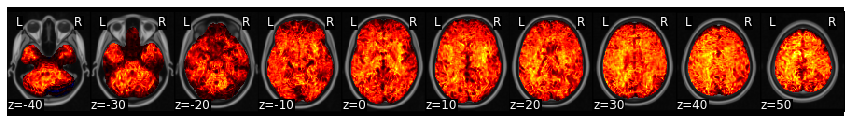

In [ ]:
# copy the bit where we loaded sub-S01's preprocessed time series
sub = 'sub-S01'
data = Brain_Data(os.path.join(data_dir, 'derivatives', 'fmriprep', sub, 'func', f'{sub}_task-localizer_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz'))

# get signal to noise ratio as indicated by the formula above
tSNR = data.mean(axis=0) / data.std(axis=0)

tSNR = (tSNR - tSNR.mean()) / tSNR.std() # mean-center and divide by standard deviation

tSNR.iplot()

## Exercise 3
We are often interested in identifying outliers in our data. In this exercise, find any image from 'S01' that exceeds a zscore of 2 and plot each one. # OG
We are often interested in identifying outliers in our data. In this exercise, find any image from 'S01' in which the average signal exceeds a zscore of 2 and plot each one.

[31, 99, 100, 101]


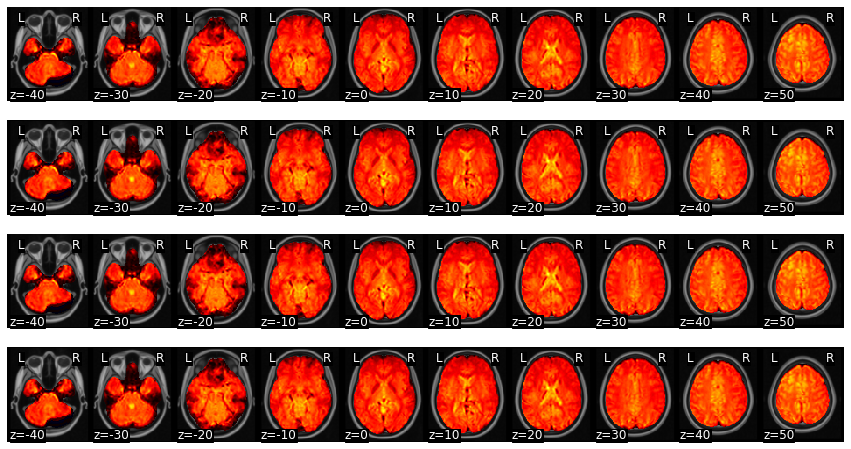

In [ ]:
# get data
sub = 'sub-S01'
data = Brain_Data(os.path.join(data_dir, 'derivatives', 'fmriprep', sub, 'func', f'{sub}_task-localizer_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz'))

# get indices of outlier images
outlier = abs((data.mean(axis = 1) - data.mean().mean())/data.mean(axis = 1).std()) > 2

# print outlier image indices
print([i for i, x in enumerate(outlier) if x])

# plot outlier images
data[outlier].plot()

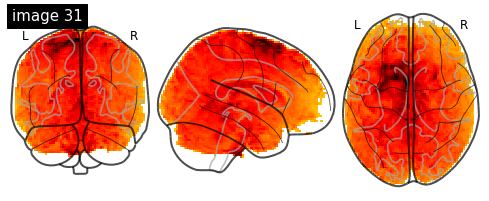

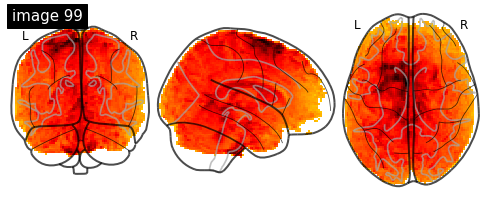

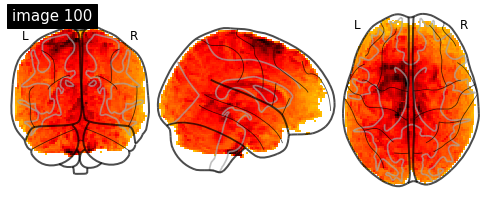

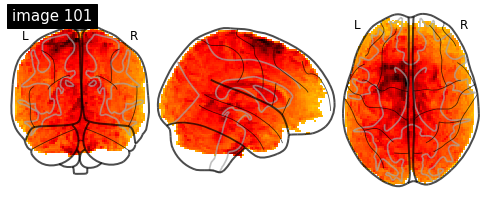

In [ ]:
# copy the bit where we loaded sub-S01's preprocessed time series
sub = 'sub-S01'
data = Brain_Data(os.path.join(data_dir, 'derivatives', 'fmriprep', sub, 'func', f'{sub}_task-localizer_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz'))

# start by getting the mean signal in each image
meanByImage = data.mean(axis=1)

# standardize to get into units of standard deviation
zData = (meanByImage - meanByImage.mean()) / meanByImage.std()

# for each image in 'data'...
for IMG in range(len(data)):

    # if the absolute z-score of the average signal in that image is > 2...
    if np.abs(zData[IMG]) > 2:

        # plot
        plot_glass_brain(data[IMG].to_nifti(),title='image ' + str(IMG)) # glass brain

Text(0, 0.5, 'standardized signal across voxels')

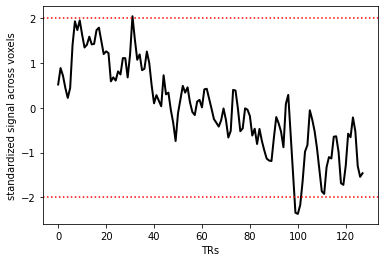

In [ ]:
f, ax = plt.subplots()
ax.plot(zData,color='k',linewidth=2,label='unfiltered')
ax.axhline(y=2, color='r', linestyle=':') # add a horizontal line at +2 standard deviations
ax.axhline(y=-2, color='r', linestyle=':') # add a horizontal line at -2 standard deviations
ax.set_xlabel('TRs')
ax.set_ylabel('standardized signal across voxels')

In [ ]:
data_hpf = data.filter(sampling_freq=1/2.4, high_pass=1/128) # (code pasted from Module 4)

# get the mean signal in each image in the high pass filtered dataset
meanByImage_hpf = data_hpf.mean(axis=1)

# standardize to get into units of standard deviation
zData_hpf = (meanByImage_hpf - meanByImage_hpf.mean()) / meanByImage_hpf.std()

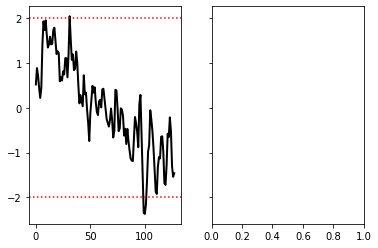

In [ ]:
f, ax = plt.subplots(ncols=2, sharey=True)
ax[0].plot(zData,color='k',linewidth=2,label='unfiltered')
ax[0].axhline(y=2, color='r', linestyle=':')
ax[0].axhline(y=-2, color='r', linestyle=':')
ax[0].set_xlabel('TRs')
ax[0].set_ylabel('standardized signal across voxels')
ax[1].plot(zData_hpf,color='m',linewidth=2,label='high pass filtered')
ax[1].axhline(y=2, color='r', linestyle=':')
ax[1].axhline(y=-2, color='r', linestyle=':')
ax[1].set_xlabel('TRs')



